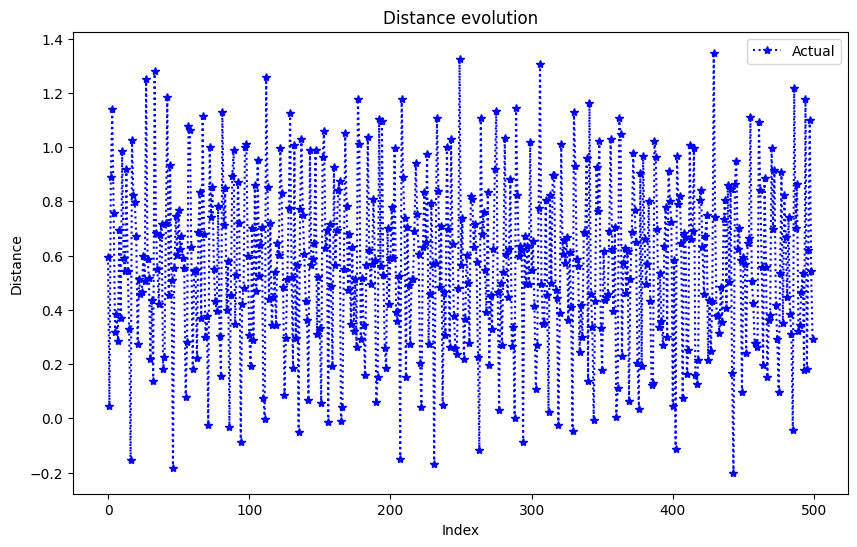

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


dataset = pd.read_csv("../dataset/riemann_features.csv")

X = dataset.drop(columns=["distance"]).to_numpy()
y = dataset["distance"].to_numpy()

limit = 250
plt.figure(figsize=(10, 6))
plt.plot(range(len(y[:limit])), y[:limit], 'b:*', label='Actual')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.title('Distance evolution')
plt.legend()
plt.show()

Amostras: 1000 | Features: 94
Target (distance): mean=0.5481, std=0.3058



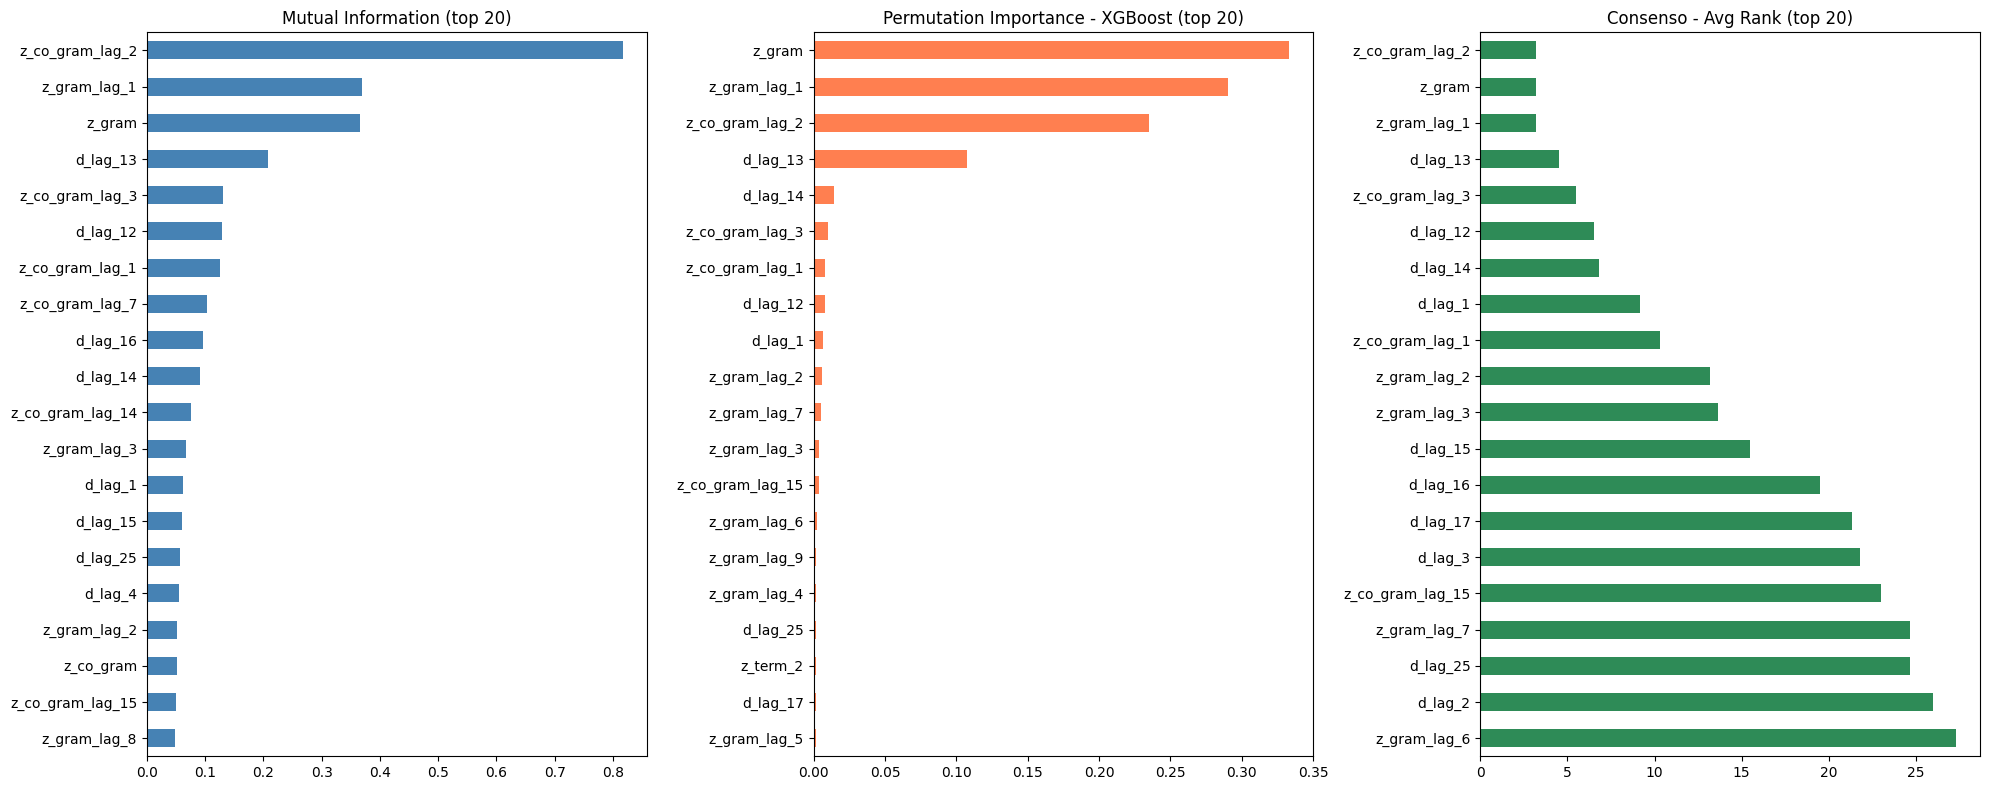


Salvos: selected_features.csv, feature_ranking_full.csv


In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression, RFE
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

TARGET = 'distance'
DATA_PATH = '../dataset/riemann_features.csv'

df = pd.read_csv(DATA_PATH)
X = df.drop(columns=[TARGET])
y = df[TARGET]
features = X.columns.tolist()

X = X[:1000]
y = y[:1000]

split = int(0.8 * len(X))
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_tr)
X_te = scaler.transform(X_te)

print(f"Amostras: {X.shape[0]} | Features: {X.shape[1]}")
print(f"Target ({TARGET}): mean={y.mean():.4f}, std={y.std():.4f}\n")

mi = mutual_info_regression(X_tr, y_tr, random_state=42, n_neighbors=5)
mi = pd.Series(mi, index=features).sort_values(ascending=False)


xgb = XGBRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, random_state=42, n_jobs=-1
)
xgb.fit(X_tr, y_tr)

perm = permutation_importance(xgb, X_te, y_te, n_repeats=15, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=features).sort_values(ascending=False)


rfe_model = XGBRegressor(
    n_estimators=100, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7, random_state=42, n_jobs=-1
)
rfe = RFE(rfe_model, n_features_to_select=10, step=5)
rfe.fit(X_tr, y_tr)
rfe_ranking = pd.Series(rfe.ranking_, index=features).sort_values()

mi_ranks = mi.rank(ascending=False)
perm_ranks = perm_imp.rank(ascending=False)
rfe_ranks = rfe_ranking.rank(ascending=True)

consensus = pd.DataFrame({
    'MI': mi_ranks,
    'Permutation': perm_ranks,
    'RFE': rfe_ranks
})
consensus['avg_rank'] = consensus.mean(axis=1)
consensus = consensus.sort_values('avg_rank')

selected = consensus.head(10).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

mi.head(20).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Mutual Information (top 20)')
axes[0].invert_yaxis()

perm_imp.head(20).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Permutation Importance - XGBoost (top 20)')
axes[1].invert_yaxis()

consensus['avg_rank'].head(20).plot(kind='barh', ax=axes[2], color='seagreen')
axes[2].set_title('Consenso - Avg Rank (top 20)')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

pd.DataFrame({'feature': selected}).to_csv('../results/data_analysis/selected_features.csv', index=False)
consensus.to_csv('../results/data_analysis/feature_ranking_full.csv')
print(f"\nSalvos: selected_features.csv, feature_ranking_full.csv")